In [1]:
from google.colab import auth
auth.authenticate_user()

In [2]:
project_id = 'prism-insights'

import bigframes.pandas as bpd
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn
import statsmodels
import prophet
from prophet import Prophet

bpd.close_session()
bpd.options.bigquery.project = project_id
bpd.options.bigquery.location = 'US'

from google.colab import syntax
df  = bpd.read_gbq(f'{project_id}.warehouse.transactions')

/usr/local/lib/python3.12/dist-packages/bigframes/session/_io/bigquery/read_gbq_table.py:379: DefaultIndexWarning: Table 'prism-insights.warehouse.transactions' is clustered and/or
partitioned, but BigQuery DataFrames was not able to find a suitable
index. To avoid this warning, set at least one of: `index_col` or
`filters`.
  warnings.warn(msg, category=bfe.DefaultIndexWarning)


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


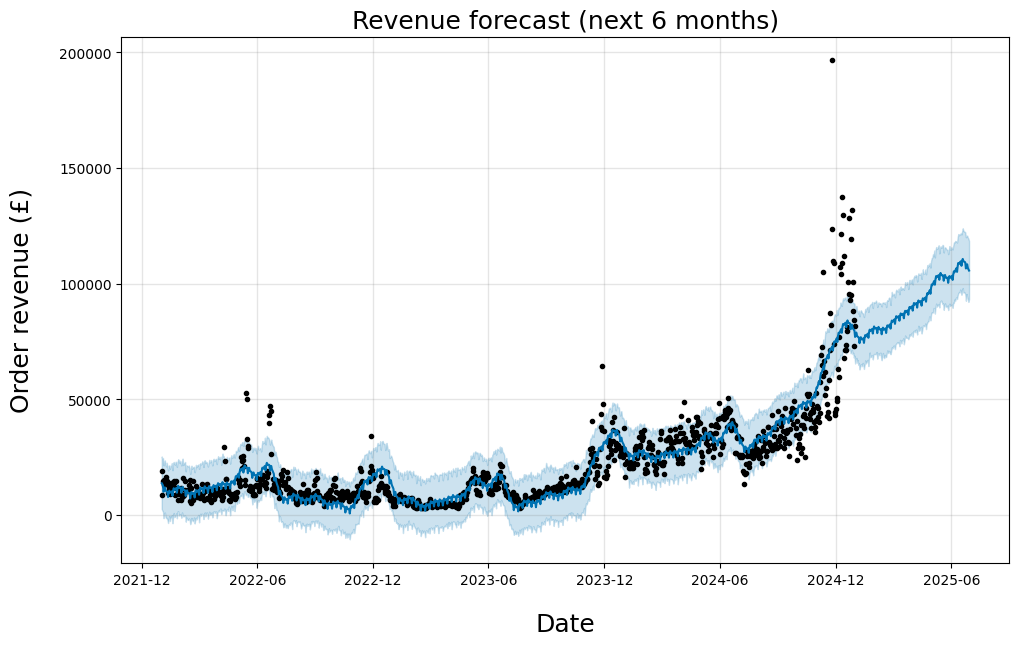

In [7]:
df_prophet = df[['date', 'transaction_revenue']].rename(
    columns={
        'date': 'ds',
        'transaction_revenue': 'y'
    }
)

# Ensure 'ds' is datetime
df_prophet['ds'] = bpd.to_datetime(df_prophet['ds'])

# Aggregate daily total revenue for Prophet
df_prophet_aggregated = df_prophet.groupby('ds')['y'].sum().reset_index()

# Convert BigQuery DataFrame to pandas DataFrame for Prophet
df_prophet_pd = df_prophet_aggregated.to_pandas()

model = Prophet()
model.fit(df_prophet_pd)

future = model.make_future_dataframe(periods=180)
forecast = model.predict(future)

fig1 = model.plot(forecast)
plt.title('Revenue forecast (next 6 months)', fontsize=18)
plt.xlabel('Date', labelpad=18, fontsize=18)
plt.ylabel('Order revenue (£)', labelpad=18, fontsize=18)
plt.show()

In [4]:
import pandas as pd

# Convert 'ds' column to datetime
forecast['ds'] = pd.to_datetime(forecast['ds'])

# Set 'ds' as index to easily resample
forecast_monthly = forecast.set_index('ds')

# Resample to monthly frequency and sum 'yhat' for monthly predictions
monthly_predictions = forecast_monthly['yhat'].resample('M').sum().reset_index()

# Rename columns for clarity
monthly_predictions.columns = ['month', 'Predicted monthly revenue (£)']

# Filter to show predictions after the historical data ends (31st Dec 2024)
# display from January 2025 onwards
filtered_monthly_predictions = monthly_predictions[monthly_predictions['month'] > '2024-12-31']

# Remove timestamp from the 'month' column for display
filtered_monthly_predictions['month'] = filtered_monthly_predictions['month'].dt.date

display(filtered_monthly_predictions.head())

/tmp/ipykernel_3905/2310468145.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_predictions = forecast_monthly['yhat'].resample('M').sum().reset_index()
/tmp/ipykernel_3905/2310468145.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_monthly_predictions['month'] = filtered_monthly_predictions['month'].dt.date


,month,Predicted monthly revenue (£)
36,2025-01-31,2.414728e+06
37,2025-02-28,2.265389e+06
38,2025-03-31,2.690071e+06
39,2025-04-30,2.791863e+06
40,2025-05-31,3.173558e+06
